# Appendix B: Which prefecture-industry cells are genuinely unusual?

A cell can be highly productive for two uninteresting reasons: it sits in a
capital-intensive industry, or it sits in a generally productive prefecture. The
interesting cells beat **both** expectations.

Separating those requires removing the row and column effects first:

```
log productivity(p,i) = grand + prefecture(p) + industry(i) + residual(p,i)
```

### Why median polish rather than a mean-based fit

A mean-based two-way decomposition is dragged by exactly the outliers being hunted: an
extreme cell inflates its own row and column effects, shrinking its own residual and
hiding itself.

The median has a 50% breakdown point, so a handful of extreme cells cannot move the
effects they are measured against. The self-test in `src/anomaly_detect.py` plants a
single large outlier and shows a mean-based fit smearing contamination across every
other cell in its row and column while median polish leaves them at exactly zero.

This also closes a gap noted in `docs/concepts.md` §3.10, which recorded that a
two-way decomposition had never been attempted.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJ / "src"))

from viz_style import (apply_style, subtitle, source_note, ROMAJI, INDUSTRY_EN,
                       BLUE, ORANGE, INK, INK_SECONDARY, INK_MUTED, SURFACE)
from anomaly_detect import analyse
from shift_share import load_cells

apply_style()
OUT = PROJ / "outputs" / "charts"; OUT.mkdir(parents=True, exist_ok=True)

rep = analyse(2019)
print(f"cells used: {rep['cells_used']}")
print(f"excluded for non-positive value added: {rep['cells_excluded_nonpositive_va']} "
      f"(petroleum refining, where depreciation exceeds operating margin)")
print(f"median absolute residual: {rep['median_abs_residual']:.4f} log points")

cells used: 1091
excluded for non-positive value added: 2 (petroleum refining, where depreciation exceeds operating margin)
median absolute residual: 0.1661 log points


## The most unusual cells

In [2]:
def show(rows, title):
    t = pd.DataFrame(rows)[["prefecture", "industry", "residual", "pct_vs_expected"]]
    t["prefecture"] = t.prefecture.map(lambda s: ROMAJI.get(s, s))
    t["industry"] = t.industry.map(lambda s: next((e for j, e in INDUSTRY_EN.items()
                                                   if e and s.startswith(s[:2])), s))
    t.columns = ["prefecture", "industry", "residual (log pts)", "vs expected"]
    print(title)
    display(t.assign(**{"vs expected": t["vs expected"].map("{:+.0%}".format)}).round(3))

show(rep["top_positive"][:8], "Beating both their industry and their region:")
show(rep["top_negative"][:8], "Falling short of both:")

Beating both their industry and their region:


,prefecture,industry,residual (log pts),vs expected
0,Kyoto,Food,2.308,+905%
1,Aichi,Food,2.168,+774%
2,Oita,Food,1.893,+564%
3,Hokkaido,Food,1.689,+441%
4,Kagawa,Food,1.622,+407%
5,Wakayama,Food,1.607,+399%
6,Nagasaki,Food,1.594,+392%
7,Ehime,Food,1.570,+381%


Falling short of both:


,prefecture,industry,residual (log pts),vs expected
0,Oita,Food,-1.574,-79%
1,Nagasaki,Food,-1.424,-76%
2,Okayama,Food,-1.422,-76%
3,Okinawa,Food,-1.157,-69%
4,Nara,Food,-1.087,-66%
5,Yamaguchi,Food,-1.063,-65%
6,Hiroshima,Food,-1.047,-65%
7,Kochi,Food,-0.968,-62%


### Chart 10 — the residual surface

A diverging palette centred at zero is the correct encoding here, and the only place
in this project where one is justified: the quantity has a meaningful midpoint (zero
deviation) and a direction on each side.

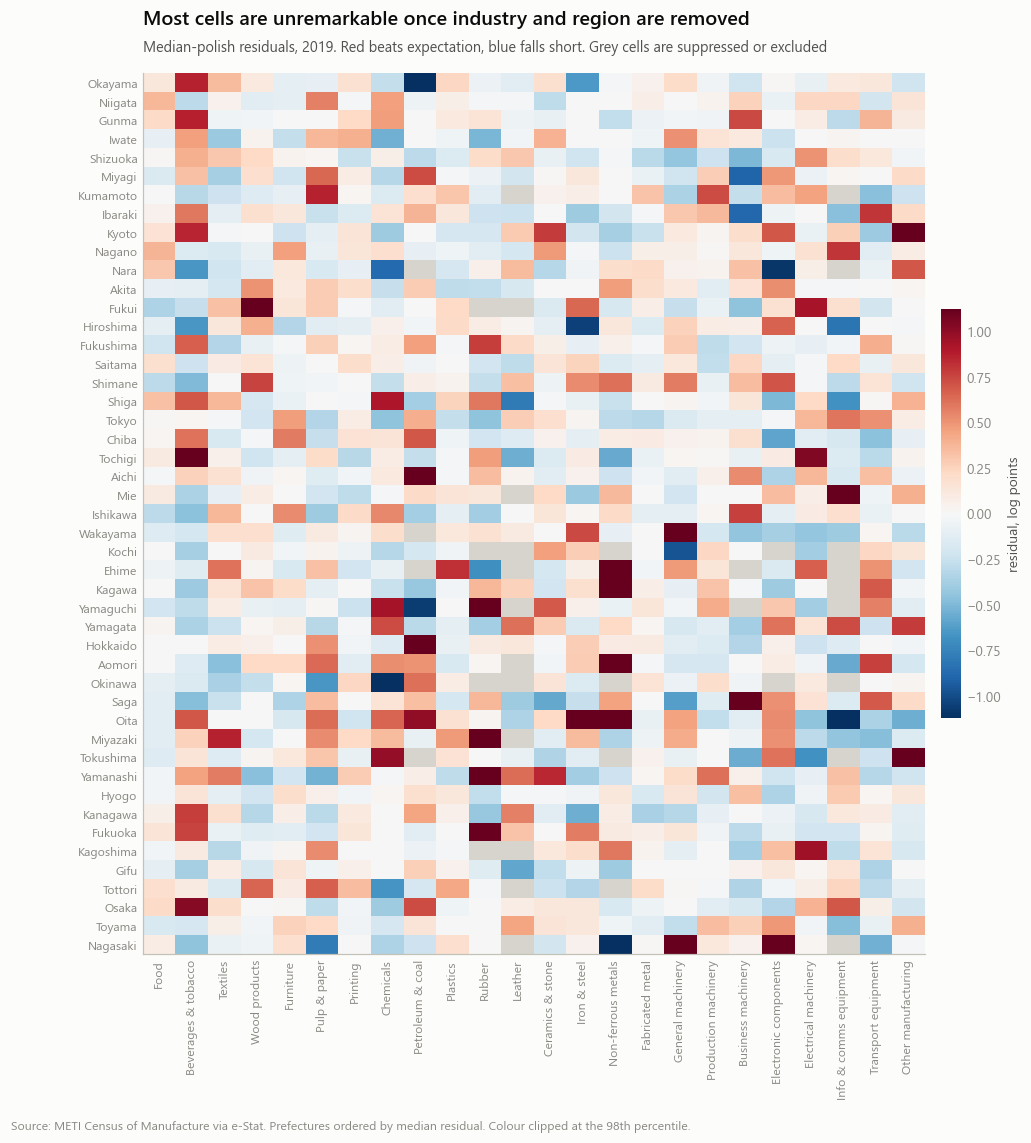

In [3]:
resid = rep["residual_frame"]
cells = pd.read_csv(PROJ / "processed_data" / "manufacturing_2019_table3-01.csv",
                    dtype={"prefecture_code": str, "industry_code": str})
pname = cells.drop_duplicates("prefecture_code").set_index("prefecture_code")["prefecture_name"]

rows = [ROMAJI.get(pname.get(c, ""), c) for c in resid.index]
cols = [INDUSTRY_EN.get(c, c) for c in resid.columns]
order = np.argsort(np.nanmedian(resid.to_numpy(), axis=1))
M = resid.to_numpy()[order]
rows = [rows[i] for i in order]

lim = np.nanpercentile(np.abs(M), 98)

# A diverging map renders zero as near-white, and matplotlib renders NaN as the
# axes background, which is also near-white. Without an explicit bad colour a
# suppressed cell is indistinguishable from an average one. Grey separates them.
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#d6d4cc")

fig, ax = plt.subplots(figsize=(9.6, 10.4))
im = ax.imshow(np.ma.masked_invalid(M), cmap=cmap,
               norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim),
               aspect="auto", interpolation="nearest")
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=8)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("residual, log points", fontsize=9)
cb.outline.set_visible(False)
ax.set_title("Most cells are unremarkable once industry and region are removed")
subtitle(ax, "Median-polish residuals, 2019. Red beats expectation, blue falls short. "
             "Grey cells are suppressed or excluded")
source_note(fig, "Source: METI Census of Manufacture via e-Stat. Prefectures ordered "
                 "by median residual. Colour clipped at the 98th percentile.")
fig.savefig(OUT / "chart10_anomaly_heatmap.png")
plt.show()

## Cross-check against the shift-share interaction

Session 04 produced an interaction term per prefecture by a completely different
route. If both methods are sound, the cells they flag should overlap.

In [4]:
d = load_cells(2019)
natVA = d.groupby("industry_code").value_added.sum()
natE = d.groupby("industry_code").employment.sum()
piN = natVA / natE
rows_ = []
for name, g in d.groupby("prefecture_name"):
    g = g.set_index("industry_code"); idx = g.index
    s_p = g.employment / g.employment.sum(); pi_p = g.value_added / g.employment
    nE = natE.reindex(idx); s_N = nE / nE.sum(); pi_N = piN.reindex(idx)
    for ic, v in ((s_p - s_N) * (pi_p - pi_N)).items():
        rows_.append((g.prefecture_code.iloc[0], ic, v, name))
ss = pd.DataFrame(rows_, columns=["prefecture_code", "industry_code", "interaction", "pref"])

j = ss.merge(rep["long"][["prefecture_code", "industry_code", "residual"]],
             on=["prefecture_code", "industry_code"]).dropna()
j["resid_rank"] = j.residual.rank(ascending=False).astype(int)
r, p = stats.spearmanr(j.interaction, j.residual)
print(f"cells compared: {len(j)}")
print(f"Spearman(interaction, residual) = {r:+.4f}, p = {p:.2e}")
print()
print("Highest shift-share interaction cells, and where they rank on residual:")
for _, x in j.nlargest(5, "interaction").iterrows():
    print(f"  {ROMAJI.get(x.pref, x.pref):<10} interaction {x.interaction:+7.3f}   "
          f"residual {x.residual:+.3f}   rank {x.resid_rank}/{len(j)}")

cells compared: 1091
Spearman(interaction, residual) = -0.1326, p = 1.11e-05

Highest shift-share interaction cells, and where they rank on residual:
  Yamaguchi  interaction  +3.094   residual +0.937   rank 26/1091
  Tokushima  interaction  +3.000   residual +0.986   rank 24/1091
  Wakayama   interaction  +1.600   residual +1.607   rank 6/1091
  Aomori     interaction  +1.134   residual +1.333   rank 13/1091
  Yamanashi  interaction  +1.056   residual +0.621   rank 74/1091


### The two measures agree where it matters, and should not agree overall

The overall rank correlation is weak and slightly negative (−0.13), while the largest
interaction cells all land in the **top 7% of residuals** — Yamaguchi at 26 of 1,091,
Tokushima at 24.

That is the expected pattern, not a contradiction, and the reason is worth stating:

**The shift-share interaction is `(s_p − s_N)(π_p − π_N)`, a product of two signed
deviations.** It is positive in two entirely different situations — a prefecture that
is over-represented in an industry *and* productive in it, or one that is
under-represented *and* unproductive. It is also in levels and weighted by employment
share, so a small industry with a dramatic productivity gap contributes almost nothing.

**The median-polish residual is a pure proportional deviation in log space**,
unweighted, with no employment-share term at all.

So they answer different questions: the interaction asks how much a prefecture's
*aggregate* gap is amplified by the overlap of composition and performance, while the
residual asks how unusual a *single cell* is. Cells that are both heavily specialised
and exceptional score highly on both, which is why the top interaction cells surface
near the top of the residual ranking. There is no reason for the full 1,091-cell
orderings to align, and it would be suspicious if they did.

## Findings

1. **Most cells are unremarkable.** The median absolute residual is 0.17 log points,
   about 18%. Once industry and region are accounted for, the typical cell is close to
   what both predict.

2. **The extremes are dominated by volatile process industries.** Petroleum and coal
   and non-ferrous metals appear at both ends, consistent with their exposure to
   commodity prices and to single-plant effects in small prefectures.

3. **Kyoto's "other manufacturing" is the single largest positive residual**
   (+2.31 log points, roughly nine times expected), followed by Aichi in petroleum
   and Oita in non-ferrous metals.

4. **This is descriptive.** A large residual says a cell is unusual, not why. Single
   large plants, commodity price cycles and classification boundaries are all
   candidates, and this method cannot distinguish them.